<a href="https://colab.research.google.com/github/sk-shahsi/ML_Model/blob/master/Customer_Segmentation_using_KMeans_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **1. Import the required packages**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Machine Learning related classes and functions
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

### **2. Reading and Exploring the Data**

In [ ]:
customers = pd.read_csv('Mall_Customers.csv')

In [ ]:
customers.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
customers.shape #print the number of rows and columns in the dataframe

(200, 5)

In [ ]:
customers.drop(columns = 'CustomerID', inplace = True)
#customers.drop('CustomerID', axis = 1, inplace = True)

In [ ]:
customers.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [ ]:
customers.isnull().sum(axis = 0)    #prints the total number of missing values column-wise

,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
customers.isnull().sum(axis = 1) > 4  #print the rows which have more than 1 missing values

,0
0,False
1,False
2,False
3,False
4,False
...,...
195,False
196,False
197,False
198,False


In [ ]:
customers = customers[customers.isnull().sum(axis = 1) <= 1] #keep the rows which have maximum of 1 missing values and remove the rest

In [ ]:
#checking for duplicates
customers.duplicated().sum()

np.int64(0)

In [ ]:
customers.drop_duplicates(inplace = True)   #drop all the duplicate rows

In [ ]:
customers.dtypes

,0
Gender,object
Age,int64
Annual Income (k$),int64
Spending Score (1-100),int64


#### **Encoding the Gender Column**

In [ ]:
le = LabelEncoder()

customers['Gender'] = le.fit_transform(customers['Gender'])

#### **Feature Engineering**

1. Outliers
2. Creating new features
3. Standardization or Normalization (Scaling of the data).
4. Encoding of the features.
5. Binning of the features.

### **3. Machine Learning Process**

In [ ]:
customers.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [ ]:
X = customers.iloc[:, 2:4].values

In [ ]:
X[0:10]

array([[15, 39],
       [15, 81],
       [16,  6],
       [16, 77],
       [17, 40],
       [17, 76],
       [18,  6],
       [18, 94],
       [19,  3],
       [19, 72]])

#### **Standardization of the data**

In [ ]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

#### **Finding Optimal K**
K-Means requires us to specify the number of clusters (K) upfront. We'll use three methods to identify the best K:
1. **WCSS or Elbow Method** : looks at how much inertia decreases as K grows
2. **Silhouette Score** : measures how well-separated the clusters are
3. **Davies-Bouldin Index** : measures cluster compactness vs separation

We test K = 2 through 10 for all three methods.

##### **a. WCSS Method or Elbow Method**
**WCSS** = The sum of squared distance of each point to its cluster centroid, within a cluster. Also known as **Inertia**.

- Lower inertia = tighter clusters (but adding more K always reduces inertia)
- Look for the "elbow" point; the point where inertia stops dropping sharply
- Beyond the elbow point, adding more clusters gives diminishing returns

In [ ]:
wcss = []

for k in range(2, 11):
  kmeans = KMeans(n_clusters = k, n_init = 10, random_state = 42)
  kmeans.fit(X) #the training starts

  print(kmeans.inertia_)
  wcss.append(kmeans.inertia_)

269.69101219276405
157.70400815035939
108.92131661364358
65.56840815571681
55.057348270385965
44.86475569922555
37.22818767758587
32.39226763033118
29.981897788243703


##### **Plot wcss and corresponding k**

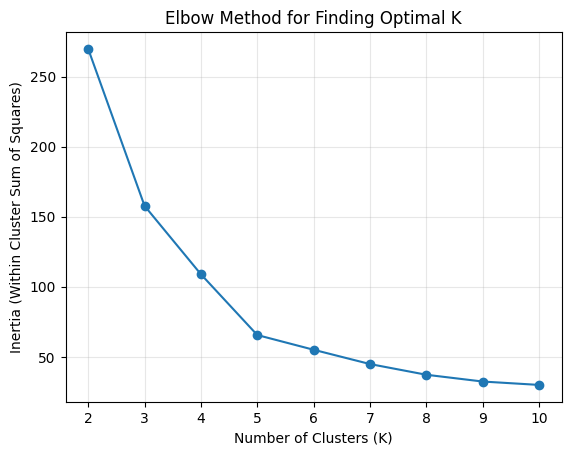

In [ ]:
plt.plot(range(2, 11), wcss, marker = 'o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within Cluster Sum of Squares)')
plt.title('Elbow Method for Finding Optimal K')
plt.xticks(range(2,11))
plt.grid(True, alpha=0.3)
plt.show()

#### **b. Silhouette Score**
The Silhouette Score measures how well each point fits its assigned cluster compared to other clusters.
- **Range:** −1 to 1
- **Higher is better**; a score near 1 means clusters are well-separated and compact
- A score near 0 means clusters overlap; negative means points may be mis-clustered

In [ ]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, n_init = 10, random_state = 42)
    labels = kmeans.fit_predict(X)

    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

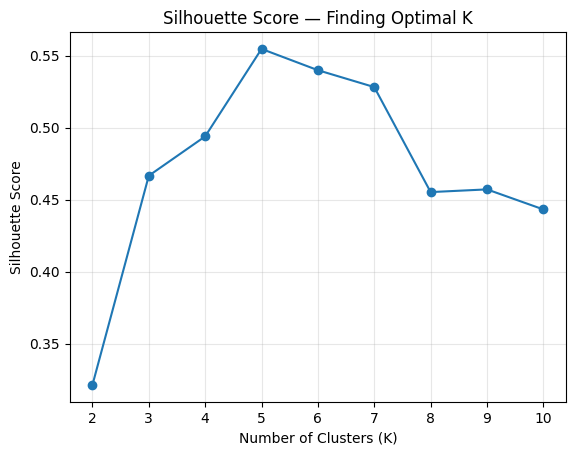

Best K by Silhouette Score: 5 (score: 0.5547)


In [ ]:
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score — Finding Optimal K')
plt.xticks(range(2, 11))
plt.grid(True, alpha=0.3)
plt.show()

best_k_silhouette = list(range(2, 11))[silhouette_scores.index(max(silhouette_scores))]
print(f"Best K by Silhouette Score: {best_k_silhouette} (score: {max(silhouette_scores):.4f})")

#### **c. Davies-Bouldin Index (DBI)**

The Davies-Bouldin Index measures the ratio of within-cluster scatter to between-cluster separation

- **Lower is better** : compact, well-separated clusters score near 0.

In [ ]:
dbi_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, n_init = 10, random_state = 42)
    labels = kmeans.fit_predict(X)
    score = davies_bouldin_score(X, labels)
    dbi_scores.append(score)

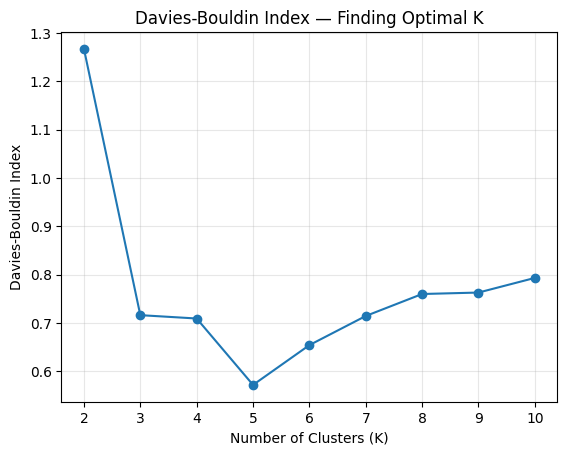

Best K by Davies-Bouldin Index: 5 (score: 0.5722)


In [ ]:
plt.plot(range(2, 11), dbi_scores, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Davies-Bouldin Index')
plt.title('Davies-Bouldin Index — Finding Optimal K')
plt.xticks(range(2, 11))
plt.grid(True, alpha=0.3)
plt.show()

best_k_dbi = list(range(2,11))[dbi_scores.index(min(dbi_scores))]
print(f"Best K by Davies-Bouldin Index: {best_k_dbi} (score: {min(dbi_scores):.4f})")

### **Apply KMeans Clustering on the data**

In [ ]:
kmeans_final = KMeans(n_clusters = 5, n_init = 10, random_state = 42)
kmeans_final.fit(X)

KMeans(n_clusters=5, n_init=10, random_state=42)

In [ ]:
y = kmeans_final.predict(X)

In [ ]:
y

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [ ]:
output = pd.DataFrame(y, columns = ['Cluster Number'])

In [ ]:
final_df = pd.concat([customers, output], axis = 1)

In [ ]:
final_df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster Number
0,1,19,15,39,4
1,1,21,15,81,2
2,0,20,16,6,4
3,0,23,16,77,2
4,0,31,17,40,4


### **Visualize the clusters**

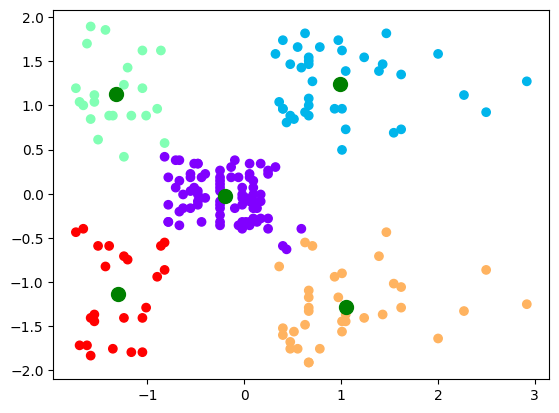

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c = y, cmap = 'rainbow')
plt.scatter(kmeans_final.cluster_centers_[:, 0], kmeans_final.cluster_centers_[:, 1], s = 100, c = 'green')
plt.show()